In [1]:
from matplotlib import pyplot as plt
from dataset import load_dataset
from classification.voting_ensemble_classifier import VotingEnsembleClassifier
import joblib
import os
plt.style.use("default")
from plot_style import set_plot_style
set_plot_style()

In [2]:
TRAIN_PATH_FULL = "../../../data/processed/full_train/train.csv"
TRAIN_PATH_SPLIT = "../../../data/processed/split_85_15/train_85.csv"
TEST_PATH_SPLIT  = "../../../data/processed/split_85_15/test_15.csv"
OUTPUT_PATH="../../../output/voting_classifier/"
MODEL_PATH = "voting.pkl"
TARGET_COL = "faulty"
FEUTURE=["trq_margin","oat","pa","np_ng_ratio","ias","mgt"]

In [3]:
train_df = load_dataset(TRAIN_PATH_SPLIT)
test_df = load_dataset(TEST_PATH_SPLIT)

X_train = train_df[FEUTURE].values
y_train = train_df[TARGET_COL].values

X_test = test_df[FEUTURE].values
y_test = test_df[TARGET_COL].values

In [6]:
voting_model=VotingEnsembleClassifier()

if os.path.exists(OUTPUT_PATH + MODEL_PATH):
    voting_model=joblib.load(OUTPUT_PATH+MODEL_PATH)
else:
    voting_model.fit(X_train,y_train)
    joblib.dump(voting_model,OUTPUT_PATH+MODEL_PATH)

In [7]:
voting_model.get_weights()

array([0.48120759, 0.22057599, 0.29821642])


ENSEMBLE (VotingClassifier)


/Users/alessandropettinaro/PycharmProjects/PHM_2024_Project/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.9991
F1 macro: 0.9990

Confusion Matrix:
[[66440    41]
 [   61 44852]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     66481
           1       1.00      1.00      1.00     44913

    accuracy                           1.00    111394
   macro avg       1.00      1.00      1.00    111394
weighted avg       1.00      1.00      1.00    111394



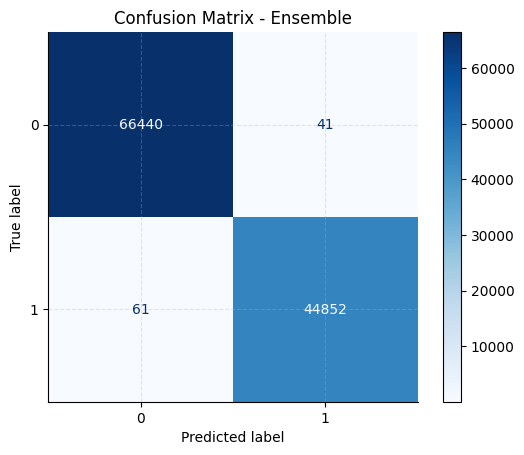


BASE MODEL: RF
Accuracy: 0.9995
F1 macro: 0.9995

Confusion Matrix:
[[66463    18]
 [   38 44875]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     66481
           1       1.00      1.00      1.00     44913

    accuracy                           1.00    111394
   macro avg       1.00      1.00      1.00    111394
weighted avg       1.00      1.00      1.00    111394



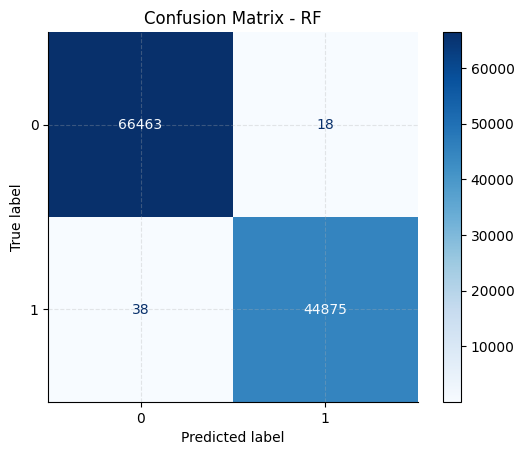


BASE MODEL: XGB
Accuracy: 0.9973
F1 macro: 0.9971

Confusion Matrix:
[[66340   141]
 [  165 44748]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     66481
           1       1.00      1.00      1.00     44913

    accuracy                           1.00    111394
   macro avg       1.00      1.00      1.00    111394
weighted avg       1.00      1.00      1.00    111394



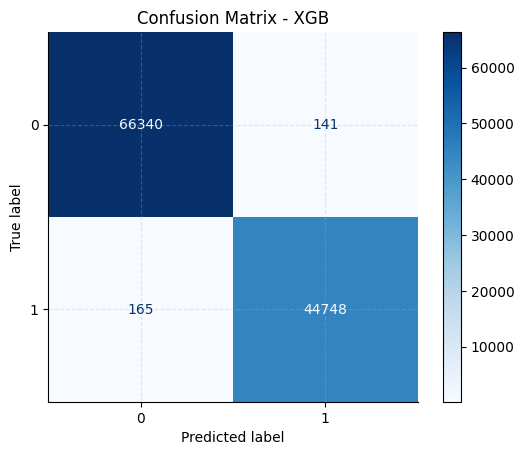


BASE MODEL: LGBM


/Users/alessandropettinaro/PycharmProjects/PHM_2024_Project/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.9982
F1 macro: 0.9982

Confusion Matrix:
[[66395    86]
 [  111 44802]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     66481
           1       1.00      1.00      1.00     44913

    accuracy                           1.00    111394
   macro avg       1.00      1.00      1.00    111394
weighted avg       1.00      1.00      1.00    111394



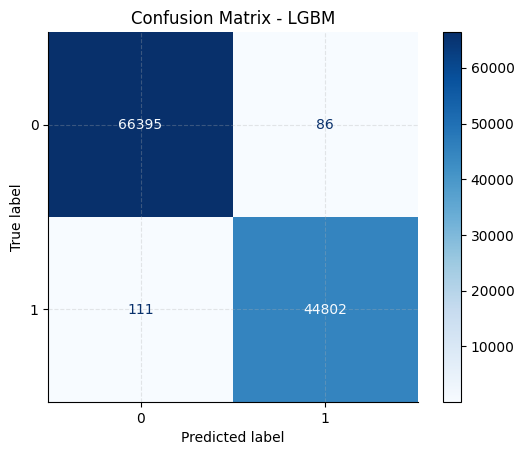

{'ensemble': {'accuracy': 0.9990843312925293,
  'f1_macro': 0.9990485986628928,
  'confusion_matrix': array([[66440,    41],
         [   61, 44852]])},
 'base_models': {'rf': {'accuracy': 0.9994972799253101,
   'f1_macro': 0.999477662011,
   'confusion_matrix': array([[66463,    18],
          [   38, 44875]])},
  'xgb': {'accuracy': 0.9972529938775877,
   'f1_macro': 0.9971457547090568,
   'confusion_matrix': array([[66340,   141],
          [  165, 44748]])},
  'lgbm': {'accuracy': 0.9982315025943946,
   'f1_macro': 0.9981624563542177,
   'confusion_matrix': array([[66395,    86],
          [  111, 44802]])}}}

In [8]:
voting_model.evaluate(X_test, y_test)

In [8]:
idx=27568
test_X_row = test_df.loc[[idx], FEUTURE]
test_y_true = test_df.loc[idx, TARGET_COL]
y_pred = voting_model.predict(test_X_row)
test_X_score=voting_model.evaluate_phm_score(test_X_row,test_y_true)
print("True class:", test_y_true)
print("Pred class:", y_pred)


PHM score (mean): 0.9814
True class: 1
Pred class: [1]


/Users/alessandropettinaro/PycharmProjects/PHM_2024_Project/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Users/alessandropettinaro/PycharmProjects/PHM_2024_Project/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Users/alessandropettinaro/PycharmProjects/PHM_2024_Project/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [9]:
voting_model.evaluate_phm_score(X_test,y_test)

/Users/alessandropettinaro/PycharmProjects/PHM_2024_Project/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/alessandropettinaro/PycharmProjects/PHM_2024_Project/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


PHM score Ensemble (mean): 0.9929
PHM score RF (mean): 0.9952
PHM score XGB (mean): 0.9877


/Users/alessandropettinaro/PycharmProjects/PHM_2024_Project/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/alessandropettinaro/PycharmProjects/PHM_2024_Project/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


PHM score LGBM (mean): 0.9909


{'ensemble_mean': 0.9928771839004182,
 'ensemble_scores': [0.9999404388897337,
  0.9995414332881382,
  0.9989338851177275,
  0.9994684253650321,
  0.9999069786300858,
  0.999918635111946,
  0.9956276679231988,
  0.9999732649524674,
  0.9974993369403555,
  0.9987300695937036,
  0.9998822207128202,
  0.9893650189117148,
  0.9997037800635327,
  0.9996000787558735,
  0.9999219109240967,
  0.9999561016490464,
  0.9927212489932782,
  0.99999290874481,
  0.9738190571026017,
  0.9998602173209714,
  0.9981151409068629,
  0.9999998895117219,
  0.983205929435734,
  0.9999991413987239,
  0.9996745496432375,
  0.9999994890320543,
  0.9999991524778502,
  0.9999500621751095,
  0.9999991395291119,
  0.9972425743942555,
  0.9999950527313219,
  0.9999966893328908,
  0.9999734844508097,
  0.9999814154394018,
  0.8706201885186106,
  0.9999138658576984,
  0.9981686683069587,
  0.9999768800542066,
  0.9999834267483727,
  0.9999882835897898,
  0.9999987324321988,
  0.9999997357428614,
  0.9539756216954893,
 